# **경로 설정하기(1. 마운트 진행하기, 2. 경로 접근하기)**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd ./drive/MyDrive/Colab/

/content/drive/MyDrive/Colab


# 모듈 불러오기

In [3]:
from keras.models import Model
from keras.layers import *
#from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from keras.regularizers import l2
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import LearningRateScheduler, ModelCheckpoint
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
import keras.backend as K
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob

# **경로 설정하기**

In [4]:
pwd

'/content/drive/MyDrive/Colab'

In [5]:

BASE_PATH = './data/sample_ct_lung/'#'./education'
IMG_DATA_PATH = os.path.join(BASE_PATH,  'input', '2d_image')#'4. U-Net', 'input', '2d_image')
MASK_DATA_PATH = os.path.join(BASE_PATH,  'input', '2d_mask')#'4. U-Net', 'input', '2d_mask')

In [6]:
IMG_DATA_PATH
MASK_DATA_PATH

'./data/sample_ct_lung/input/2d_mask'

# **하이퍼 파라미터**
하이퍼 파라미터를 이용해 인공지능 모델을 조정합니다.  
주로 사용하는 하이퍼 파라미터는 다음과 같습니다.

In [7]:
IMG_HEIGHT, IMG_WIDTH = (96, 96) # 이미지 사이즈
EPOCHS = 30                      # 훈련 횟수
BATCH_SIZE = 5                   # 한번에 입력할 데이터 개수
INIT_FILTERS = 32                # 모델 채널 크기
LEARNING_RATE = 2e-4             # 학습률
DECAY_RATE = 0.9                 # 학습률 감소 비율
ACTIVATION_FN = 'relu'            # 활성함수 ex: relu, elu, sigmoid
DROP_RATE = 0.25                 # 드롭아웃 비율
VAL_RATIO = 0.2                  # 검증 데이터 비율

# **데이터 불러오기**

이미지와 레이블 데이터를 불러옵니다.  
glob.glob 함수를 이용해 경로에 있는 파일들을 검색할 수 있습니다.

In [8]:
img_path = sorted(glob.glob(os.path.join(IMG_DATA_PATH, '*.jpg')))
mask_path = sorted(glob.glob(os.path.join(MASK_DATA_PATH, '*.jpg')))

In [9]:
img_path

['./data/sample_ct_lung/input/2d_image/ID_0000_Z_0142.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0001_Z_0146.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0002_Z_0162.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0003_Z_0132.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0004_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0005_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0006_Z_0206.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0007_Z_0211.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0008_Z_0065.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0009_Z_0114.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0010_Z_0259.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0011_Z_0156.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0012_Z_0167.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0013_Z_0047.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0014_Z_0116.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0015_Z_0136.jpg',
 './data/sample_ct_lung/input/2d_image/I

In [10]:
mask_path

['./data/sample_ct_lung/input/2d_mask/ID_0000_Z_0142.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0001_Z_0146.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0002_Z_0162.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0003_Z_0132.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0004_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0005_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0006_Z_0206.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0007_Z_0211.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0008_Z_0065.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0009_Z_0114.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0010_Z_0259.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0011_Z_0156.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0012_Z_0167.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0013_Z_0047.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0014_Z_0116.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0015_Z_0136.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0016_Z_0208.jpg

모아놓은 파일들을 다음 함수를 이용해 불러옵니다.

In [11]:
def load_and_resize_png1(path, img_height, img_width):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_AREA)
    return img

def load_and_resize_png2(path, img_height, img_width):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_NEAREST)
    return img

def load_and_resize_nii(path, img_height, img_width):
    img = nb.load(path).get_data()
    img = np.transpose(np.squeeze(img), (1, 0))
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_AREA).astype(np.uint8)
    return img

불러온 이미지의 형태는 다음과 같이 (263, 96, 96) 입니다.  
***263*** 장의 세로 ***96***, 가로 ***96*** 의 이미지를 불러왔다는 의미입니다.

In [13]:
imgs = np.stack([load_and_resize_png1(i_path, IMG_HEIGHT, IMG_HEIGHT) for i_path in img_path])
print(imgs.shape)
masks = np.stack([load_and_resize_png2(m_path, IMG_HEIGHT, IMG_HEIGHT) for m_path in mask_path])
print(masks.shape)
pred_masks = np.stack([load_and_resize_png2(m_path, IMG_HEIGHT, IMG_HEIGHT) for m_path in mask_path])
print(pred_masks.shape)

(263, 96, 96)
(263, 96, 96)
(263, 96, 96)




**왼쪽 이미지**는 우리가 AI 모델에 넣을 **인풋 이미지**고,  
**오른쪽 이미지**는 AI 모델을 학습시킬 때 필요한 정답, 즉 **레이블 이미지**입니다.

레이블 이미지와 같이 우리는 폐 영역을 분리해내는 AI 모델을 만들어 보겠습니다.

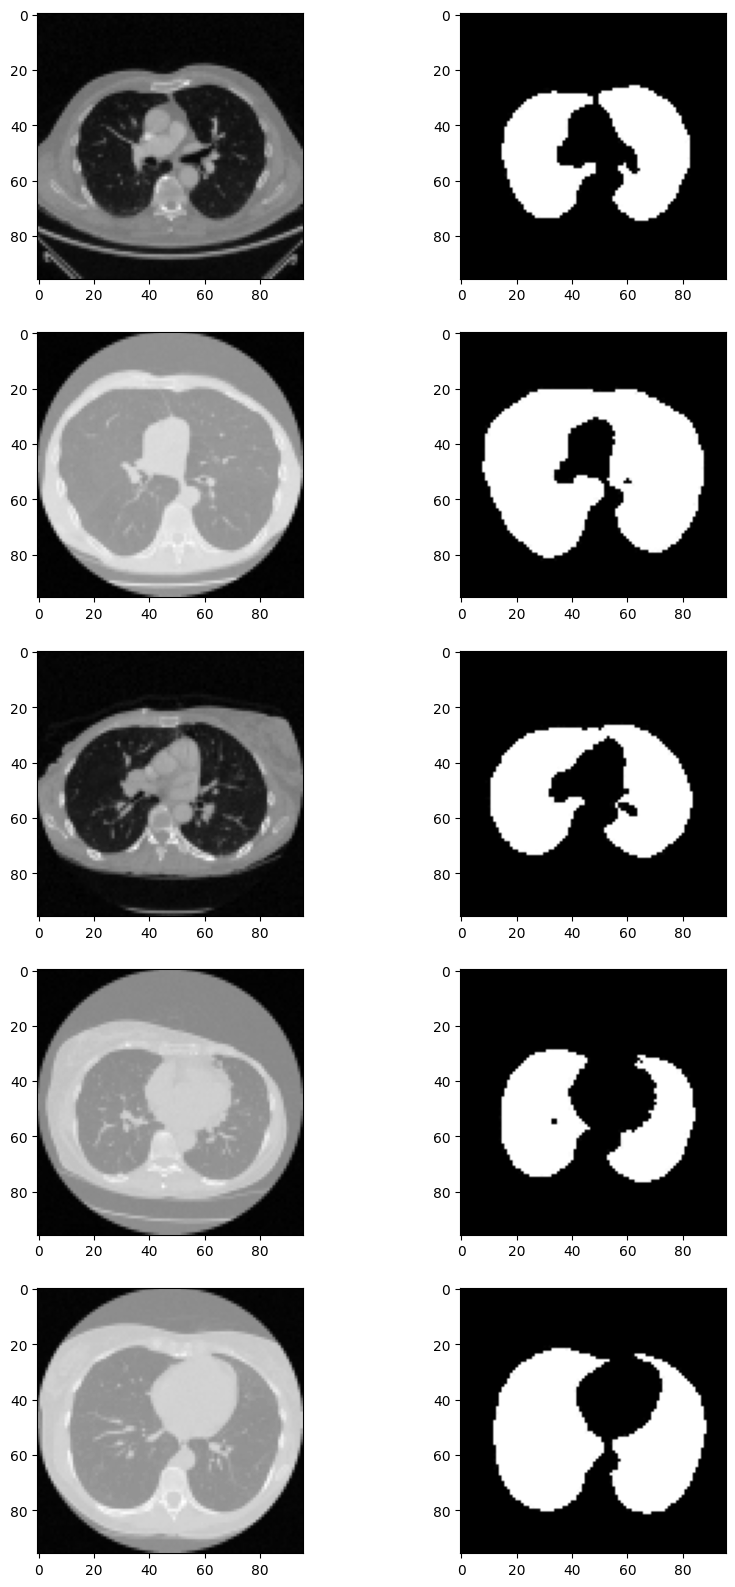

In [14]:
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    ax[i,0].imshow(imgs[i], cmap='gray')
    ax[i,1].imshow(masks[i], cmap='gray')
plt.show()

# **데이터 전처리**

AI 모델을 만들기 이전에 모델 학습에 도움을 줄 데이터 전처리를 살펴보겠습니다.  
이 과정을 통해 **AI 모델이 받아들이기 쉬운 형태로 데이터를 가공** 하여 학습 성능을 올릴 수 있습니다.  


먼저, 위에서 본 이미지 데이터를 컴퓨터가 실제로 인식하는 숫자 데이터로 확인해보겠습니다.

array([[14, 17, 16, ..., 16, 17, 15],
       [16, 14, 17, ..., 16, 14, 16],
       [15, 15, 14, ..., 16, 17, 15],
       ...,
       [14, 15, 16, ..., 16, 15, 15],
       [14, 13, 17, ..., 18, 15, 16],
       [14, 16, 15, ..., 15, 15, 17]], dtype=uint8)
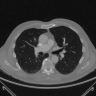

In [15]:
imgs[0]

범위가 넓고 단위가 큰 숫자들을 정규화하여 학습 성능을 높여봅시다.  


In [16]:
n_imgs = len(imgs)
imgs = np.reshape(imgs, (n_imgs, -1))
imgs_t = np.transpose(imgs, (1,0))
imgs_t_norm = (imgs_t - np.mean(imgs_t, axis=0)) / np.std(imgs_t, axis=0)
imgs = np.transpose(imgs_t_norm, (1,0))
imgs = np.reshape(imgs, (n_imgs, IMG_HEIGHT, IMG_WIDTH))

다시 값을 확인해 봅시다.

In [17]:
imgs[0]

array([[-0.95900571, -0.89648266, -0.91732367, ..., -0.91732367,
        -0.89648266, -0.93816469],
       [-0.91732367, -0.95900571, -0.89648266, ..., -0.91732367,
        -0.95900571, -0.91732367],
       [-0.93816469, -0.93816469, -0.95900571, ..., -0.91732367,
        -0.89648266, -0.93816469],
       ...,
       [-0.95900571, -0.93816469, -0.91732367, ..., -0.91732367,
        -0.93816469, -0.93816469],
       [-0.95900571, -0.97984673, -0.89648266, ..., -0.87564164,
        -0.93816469, -0.91732367],
       [-0.95900571, -0.91732367, -0.93816469, ..., -0.93816469,
        -0.93816469, -0.89648266]])

그 후 AI 모델에 넣을 수 있는 형태로 이미지 형태를 변형해 보겠습니다.

In [18]:
print('변경 전 형태: ', np.shape(imgs))
imgs = imgs[:,:,:,np.newaxis]
masks = masks[:,:,:,np.newaxis]
pred_masks = pred_masks[:,:,:,np.newaxis]
print('변경 후 형태: ', np.shape(imgs))
print('masks 변경 후 형태: ', np.shape(masks))

변경 전 형태:  (263, 96, 96)
변경 후 형태:  (263, 96, 96, 1)
masks 변경 후 형태:  (263, 96, 96, 1)


마지막으로, 데이터를 학습용 데이터와 검증용 데이터로 나누어 봅시다.  
**학습용 데이터**는 실제로 **모델 학습에 사용** 되는 데이터이고,  
**검증용 데이터**는 학습에 사용하지 않고 학습이 잘 이뤄지는 지 **성능 확인하는 용도**로 사용합니다.

In [19]:
imgs_train, imgs_val, masks_train, masks_val = train_test_split(imgs, masks, test_size=VAL_RATIO)
print('훈련 데이터 개수: ', len(imgs_train))
print('검증 데이터 개수: ', len(imgs_val))

훈련 데이터 개수:  210
검증 데이터 개수:  53


# 폐 영역 분리 AI 모델 만들기

Convolutional layer 함수 만들기

In [20]:
imgs_train.shape[1:]

(96, 96, 1)

In [21]:
def attention_up_and_concate(down_layer, layer, data_format='channels_last'):
    if data_format == 'channels_first':
        in_channel = down_layer.get_shape().as_list()[1]
    else:
        in_channel = down_layer.get_shape().as_list()[3]

    up = UpSampling2D(size=(2, 2), data_format=data_format)(down_layer)

    layer = attention_block_2d(x=layer, g=up, inter_channel=in_channel // 4, data_format=data_format)

    if data_format == 'channels_first':
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=1))
    else:
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=3))

    concate = my_concat([up, layer])
    return concate


def attention_block_2d(x, g, inter_channel, data_format='channels_last'):

    theta_x = Conv2D(inter_channel, [1, 1], strides=[1, 1], data_format=data_format)(x)

    phi_g = Conv2D(inter_channel, [1, 1], strides=[1, 1], data_format=data_format)(g)

    f = Activation('relu')(add([theta_x, phi_g]))

    psi_f = Conv2D(1, [1, 1], strides=[1, 1], data_format=data_format)(f)

    rate = Activation('sigmoid')(psi_f)

    att_x = multiply([x, rate])

    return att_x

In [22]:
inputs = Input(shape=imgs_train.shape[1:])

x = inputs
depth = 4
features = INIT_FILTERS/2
skips = []
n_label = 1# 데이터 차원
data_format='channels_last'
for i in range(depth):
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
    skips.append(x)
    x = MaxPooling2D((2, 2), data_format=data_format)(x)
    features = features * 2

x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)

for i in reversed(range(depth)):
    features = features // 2
    x = attention_up_and_concate(x, skips[i], data_format=data_format)
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)
    x = Conv2D(features, (3, 3), activation='relu', padding='same', data_format=data_format)(x)

conv6 = Conv2D(n_label, (1, 1), padding='same', data_format=data_format, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=conv6)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 96, 96, 16)           160       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 96, 96, 16)           2320      ['conv2d[0][0]']              
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 48, 48, 16)           0         ['conv2d_1[0][0]']            
 D)                                                                                           

# 미리 훈련시킨 AI 모델 파일 불러오기

AI 모델을 처음부터 훈련시켜도 되지만,  
미리 훈련시킨 모델 파일이 있는 경우 불러와서 훈련시킬 수도 있습니다.

In [ ]:
# model.load_weights('lung_seg2.h5')

# AI 모델 옵션 설정하기

AI 모델을 만든 후 여러가지 훈련 옵션을 설정할 수 있습니다.  
학습률(Learning_rate) 과 손실함수(Loss function), 정확도 기준(Dice_score) 등을 설정해 봅시다.

먼저 정확도 기준으로 Dice score 를 살펴봅시다.  

In [23]:
 def dice_score(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

옵션은 complie 을 통해 설정할 수 있습니다.  
모델의 값을 학습시키는 **Optimizer** 는 **Adam** 을 사용하고,  
정답 레이블과 예측값 사이의 차이를 계산하는 **손실 함수**는 **Cross entropy** 를 사용했습니다.   
마지막으로 **정확도 판단 기준**으로는 위에서 만든 **Dice score** 를 사용합니다.

In [24]:
model.compile(optimizer=Adam(LEARNING_RATE), loss='binary_crossentropy', metrics=[dice_score])

추가적으로 AI 모델 훈련 파일을 lung.h5 라는 파일로 저장해 다음에 사용할 수 있도록 했고,  
학습이 진행될 수록 학습률(Learning_rate)를 감소시켜 세밀한 조정이 가능하게 했습니다.

In [25]:
weight_saver = ModelCheckpoint('./lung_seg2.h5', monitor='val_dice_score', save_best_only=True, save_weights_only=True)
decayed_lr = LearningRateScheduler(lambda x: LEARNING_RATE * DECAY_RATE ** x)

# AI 모델 훈련하기

이렇게 준비한 AI 모델을 fit 함수를 이용해 훈련시킬 수 있습니다.

In [26]:
history = model.fit(imgs_train, masks_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(imgs_val, masks_val),
                    shuffle=True,
                    verbose=2,
                    callbacks=[weight_saver, decayed_lr])

Epoch 1/30
42/42 - 14s - loss: 0.5299 - dice_score: 0.3171 - val_loss: 0.3256 - val_dice_score: 0.4588 - lr: 2.0000e-04 - 14s/epoch - 340ms/step
Epoch 2/30
42/42 - 1s - loss: 0.2814 - dice_score: 0.5563 - val_loss: 0.2097 - val_dice_score: 0.7318 - lr: 1.8000e-04 - 538ms/epoch - 13ms/step
Epoch 3/30
42/42 - 1s - loss: 0.2168 - dice_score: 0.6912 - val_loss: 0.1680 - val_dice_score: 0.7546 - lr: 1.6200e-04 - 577ms/epoch - 14ms/step
Epoch 4/30
42/42 - 1s - loss: 0.1437 - dice_score: 0.7940 - val_loss: 0.1015 - val_dice_score: 0.8546 - lr: 1.4580e-04 - 595ms/epoch - 14ms/step
Epoch 5/30
42/42 - 1s - loss: 0.0927 - dice_score: 0.8722 - val_loss: 0.0701 - val_dice_score: 0.8997 - lr: 1.3122e-04 - 567ms/epoch - 14ms/step
Epoch 6/30
42/42 - 1s - loss: 0.0759 - dice_score: 0.8971 - val_loss: 0.0573 - val_dice_score: 0.9181 - lr: 1.1810e-04 - 557ms/epoch - 13ms/step
Epoch 7/30
42/42 - 1s - loss: 0.0573 - dice_score: 0.9212 - val_loss: 0.0523 - val_dice_score: 0.9309 - lr: 1.0629e-04 - 527ms/epo

# 훈련 결과 확인하기

훈련 결과를 한 눈에 확인할 수 있는 그래프를 만들어 보겠습니다.

먼저 그래프의 y축에 사용할 값들을 history 항목에서 추출해 봅시다.

In [27]:
dice_score = history.history['dice_score']
val_dice_score = history.history['val_dice_score']
loss = history.history['loss']
val_loss = history.history['val_loss']

다음으로 그래프의 x축 값으로 사용할 epoch 을 뽑아 보겠습니다.

In [28]:
epochs = range(len(dice_score))

각 값들을 확인해볼까요?

In [29]:
dice_score

[0.31707897782325745,
 0.5562502145767212,
 0.6911796927452087,
 0.794034481048584,
 0.8721674680709839,
 0.8970978260040283,
 0.9212037324905396,
 0.9320732355117798,
 0.9355273246765137,
 0.9407254457473755,
 0.9424187541007996,
 0.9447497129440308,
 0.9469389319419861,
 0.9488041996955872,
 0.9498828649520874,
 0.9506201148033142,
 0.951968789100647,
 0.9519962072372437,
 0.9530979990959167,
 0.9540819525718689,
 0.954420268535614,
 0.9551703929901123,
 0.9557176232337952,
 0.9564875364303589,
 0.9566908478736877,
 0.9566614031791687,
 0.9571352601051331,
 0.9577544331550598,
 0.9579132795333862,
 0.9582535028457642]

In [30]:
val_dice_score

[0.45875537395477295,
 0.7318320870399475,
 0.7546215057373047,
 0.8545970320701599,
 0.899698793888092,
 0.9180689454078674,
 0.9309329390525818,
 0.9299463629722595,
 0.9396668076515198,
 0.9425705075263977,
 0.9442503452301025,
 0.9458491802215576,
 0.9490261077880859,
 0.9491857886314392,
 0.9506397247314453,
 0.9513490200042725,
 0.9506503939628601,
 0.9536796808242798,
 0.9536609053611755,
 0.9528769850730896,
 0.9546302556991577,
 0.9557649493217468,
 0.9560655951499939,
 0.9565856456756592,
 0.9559754729270935,
 0.9573169350624084,
 0.9569402933120728,
 0.9575977921485901,
 0.9579007625579834,
 0.9581493735313416]

In [31]:
loss

[0.5298685431480408,
 0.28136157989501953,
 0.21684394776821136,
 0.14366716146469116,
 0.09267733991146088,
 0.07591710984706879,
 0.05727985128760338,
 0.050885144621133804,
 0.047507092356681824,
 0.044034313410520554,
 0.042551737278699875,
 0.041089363396167755,
 0.039235420525074005,
 0.03829850256443024,
 0.037244077771902084,
 0.03668574243783951,
 0.03581227734684944,
 0.03602103143930435,
 0.03455745428800583,
 0.03418942540884018,
 0.03399963304400444,
 0.03318193554878235,
 0.03279878571629524,
 0.03256172314286232,
 0.03222008794546127,
 0.03232493996620178,
 0.031687166541814804,
 0.03160881996154785,
 0.031498413532972336,
 0.031158672645688057]

In [32]:
val_loss

[0.3255833387374878,
 0.2097310721874237,
 0.16795654594898224,
 0.10154637694358826,
 0.07014676928520203,
 0.05725403502583504,
 0.05233284831047058,
 0.05408218130469322,
 0.0450163334608078,
 0.04267311468720436,
 0.042823921889066696,
 0.04050571471452713,
 0.03874896466732025,
 0.03902869299054146,
 0.03752213716506958,
 0.03821827843785286,
 0.03958730772137642,
 0.035621367394924164,
 0.03577743098139763,
 0.036515191197395325,
 0.0348799005150795,
 0.033985357731580734,
 0.03382972627878189,
 0.033429503440856934,
 0.03387973830103874,
 0.03308570012450218,
 0.03364689648151398,
 0.03300018236041069,
 0.03273097053170204,
 0.0325065441429615]

이 값들을 이용해 그래프를 만들어 보겠습니다.  

먼저 정확도 그래프를 그려볼까요?

<ipython-input-33-45962a1c004e>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, dice_score, 'b', color='blue', label='Training score')
<ipython-input-33-45962a1c004e>:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_dice_score, 'b', color='red', label='Validation score')


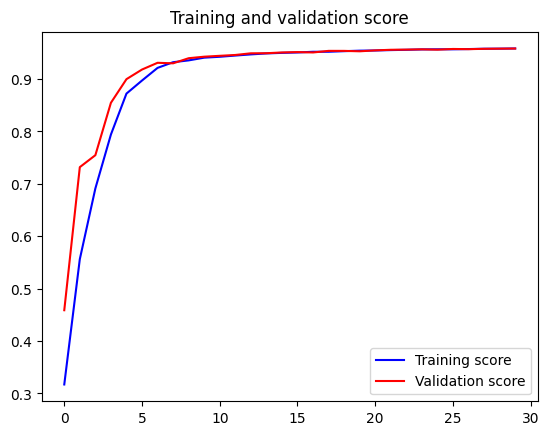

In [33]:
plt.plot(epochs, dice_score, 'b', color='blue', label='Training score')
plt.plot(epochs, val_dice_score, 'b', color='red', label='Validation score')
plt.title('Training and validation score')
plt.legend()
plt.show()

다음으로 손실 그래프를 살펴보겠습니다.

<ipython-input-34-cbd9e51137d7>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', color='blue', label='Training loss')
<ipython-input-34-cbd9e51137d7>:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', color='red', label='Validation loss')


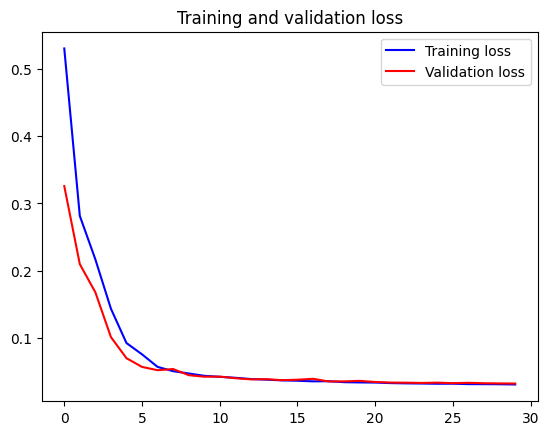

In [34]:
plt.plot(epochs, loss, 'b', color='blue', label='Training loss')
plt.plot(epochs, val_loss, 'b', color='red', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# 이미지로 결과 확인하기

마지막으로 AI 모델이 실제로 폐 영역을 잘 분리하는지 이미지로 결과를 확인해 보겠습니다.

1/1 [==============================] - 0s 19ms/step


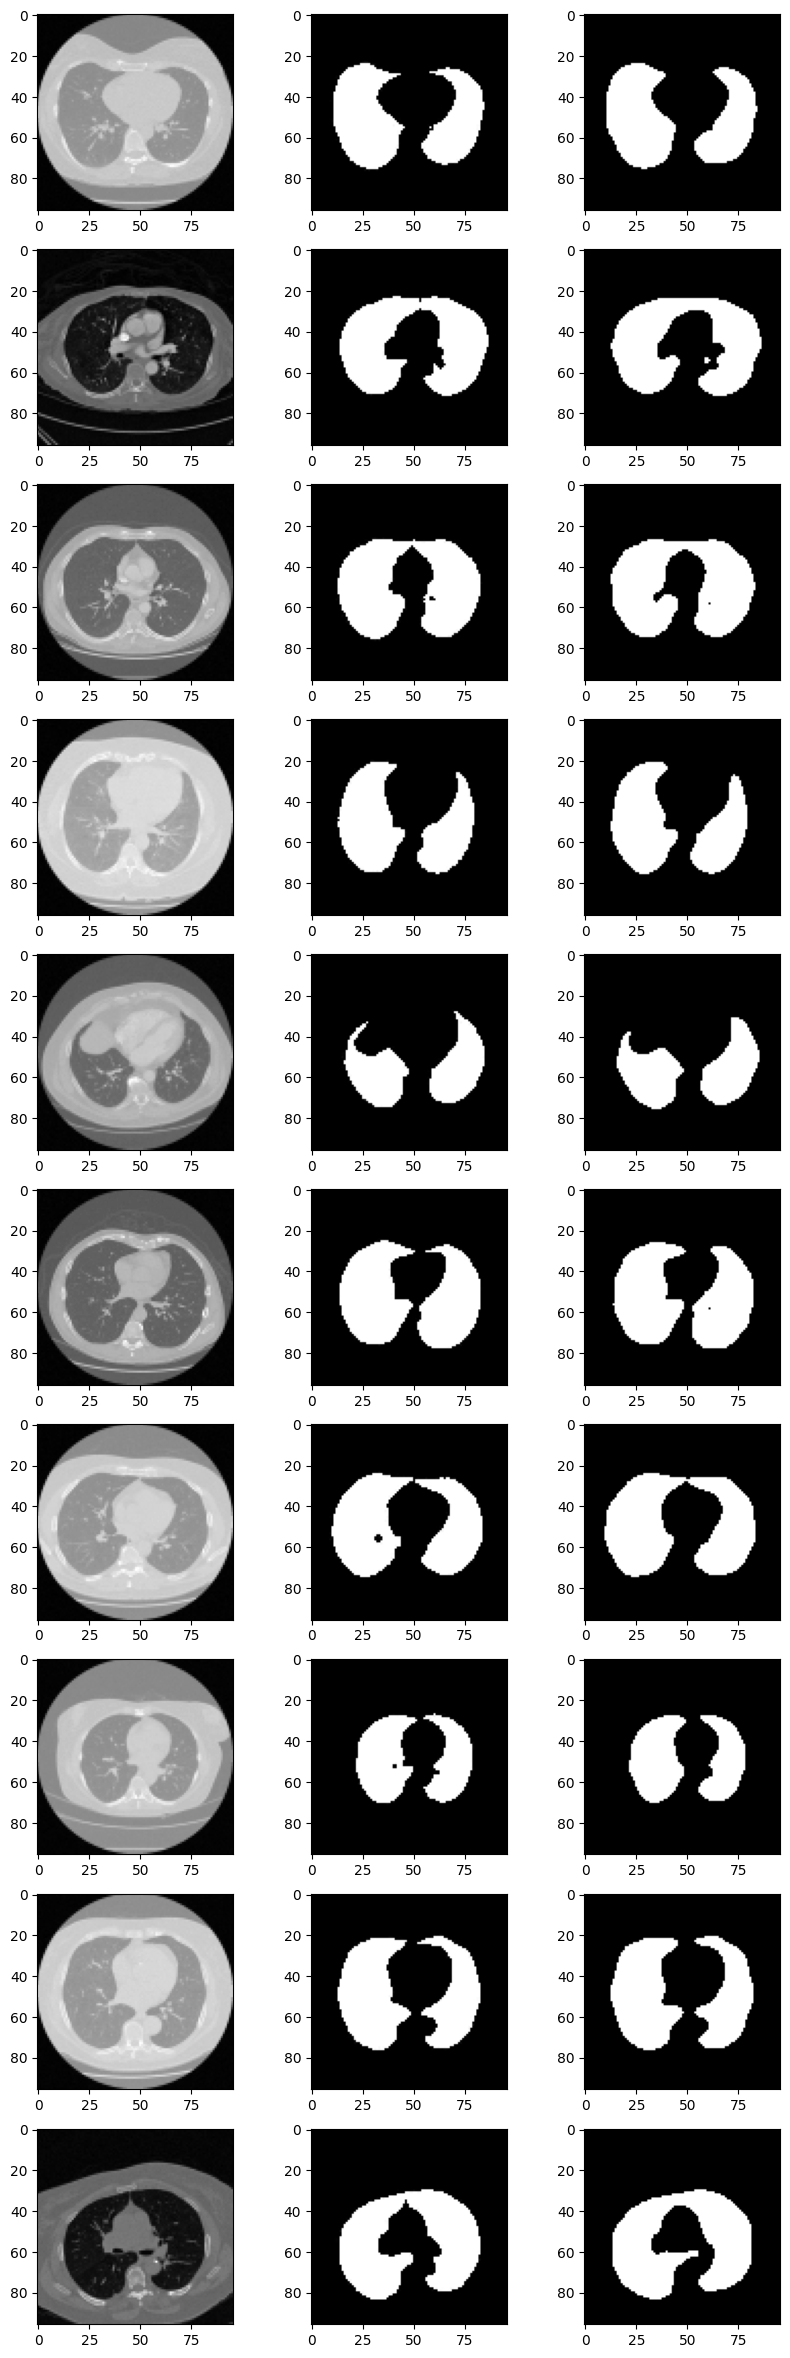

In [35]:
fix, ax = plt.subplots(10, 3, figsize=(10,30))
for i in range(10):
    pred = model.predict(imgs_train[i][np.newaxis, :, : ,:])
    mask = (pred >= 0.5).astype(np.uint8)
    pred_masks[i, :, :, 0] = mask[0, :, :, 0]
    ax[i, 0].imshow(imgs_train[i, :, :, 0], cmap='gray')
    ax[i, 1].imshow(masks_train[i, :, :, 0], cmap='gray')
    ax[i, 2].imshow(mask[0, :, :, 0], cmap='gray')
plt.show()

In [36]:
len(imgs_val)

53

In [37]:
recall_list = []
precision_list = []
acc_list = []
dice_list = []

for i in range(10):
    seg1 = pred_masks[i]
    gt1 = masks_train[i]

    seg1_n = seg1 == 0
    seg1_t = seg1 == 1

    gt1_n = gt1 == 0
    gt1_t = gt1 == 1

    tp = np.sum(seg1_t&gt1_t)

    fp = np.sum(seg1_t&gt1_n)

    tn = np.sum(seg1_n&gt1_n)

    fn = np.sum(gt1_t&seg1_n)

    recall = tp / (tp + fn)
    recall_list.append(recall)

    precision = tp / (tp+fp)
    precision_list.append(precision)

    acc = (tp + tn) / (tp + tn + fp + fn)
    acc_list.append(acc)

    dice = (2*tp) / (2*tp + fp + fn)
    dice_list.append(dice)

recall_list = np.array(recall_list)
recall_list = recall_list[~np.isnan(recall_list)]
precision_list = np.array(precision_list)
precision_list = precision_list[~np.isnan(precision_list)]
acc_list = np.array(acc_list)
acc_list = acc_list[~np.isnan(acc_list)]
dice_list = np.array(dice_list)
dice_list = dice_list[~np.isnan(dice_list)]
print('Recall : ', np.mean(recall_list))
print('Precision : ', np.mean(precision_list))
print('Accuracy : ', np.mean(acc_list))
print('DSC : ', np.mean(dice_list))
print('-'*40)
print('Recall : ', np.std(recall_list))
print('Precision : ', np.std(precision_list))
print('Accuracy : ', np.std(acc_list))
print('DSC : ', np.std(dice_list))

Recall :  0.9819082531054706
Precision :  0.9805599335682859
Accuracy :  0.9921956550935386
DSC :  0.981171413752063
----------------------------------------
Recall :  0.00799526757621446
Precision :  0.010978571846932614
Accuracy :  0.0020736338220999225
DSC :  0.005651563400099885


In [38]:
fix, ax = plt.subplots(53, 3, figsize=(10,160))
for i in range(53):
    pred = model.predict(imgs_val[i][np.newaxis, :, : ,:])
    mask = (pred >= 0.5).astype(np.uint8)
    ax[i, 0].imshow(imgs_val[i, :, :, 0], cmap='gray')
    ax[i, 1].imshow(masks_val[i, :, :, 0], cmap='gray')
    ax[i, 2].imshow(mask[0, :, :, 0], cmap='gray')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [39]:
recall_list = []
precision_list = []
acc_list = []
dice_list = []

for i in range(len(imgs_val)):
    seg1 =  pred_masks[i]
    gt1 = masks_val[i]

    seg1_n = seg1 == 0
    seg1_t = seg1 == 1

    gt1_n = gt1 == 0
    gt1_t = gt1 == 1

    tp = np.sum(seg1_t&gt1_t)

    fp = np.sum(seg1_t&gt1_n)

    tn = np.sum(seg1_n&gt1_n)

    fn = np.sum(gt1_t&seg1_n)

    recall = tp / (tp + fn)
    recall_list.append(recall)

    precision = tp / (tp+fp)
    precision_list.append(precision)

    acc = (tp + tn) / (tp + tn + fp + fn)
    acc_list.append(acc)

    dice = (2*tp) / (2*tp + fp + fn)
    dice_list.append(dice)

recall_list = np.array(recall_list)
recall_list = recall_list[~np.isnan(recall_list)]
precision_list = np.array(precision_list)
precision_list = precision_list[~np.isnan(precision_list)]
acc_list = np.array(acc_list)
acc_list = acc_list[~np.isnan(acc_list)]
dice_list = np.array(dice_list)
dice_list = dice_list[~np.isnan(dice_list)]
print('Recall : ', np.mean(recall_list))
print('Precision : ', np.mean(precision_list))
print('Accuracy : ', np.mean(acc_list))
print('DSC : ', np.mean(dice_list))
print('-'*40)
print('Recall : ', np.std(recall_list))
print('Precision : ', np.std(precision_list))
print('Accuracy : ', np.std(acc_list))
print('DSC : ', np.std(dice_list))

Recall :  0.7336302910695561
Precision :  0.7575000554189656
Accuracy :  0.8812889964230171
DSC :  0.720405843069296
----------------------------------------
Recall :  0.1869595993825595
Precision :  0.13443155764193246
Accuracy :  0.043905446657463765
DSC :  0.11598741423406486
